# Telecom Customer Complaint Prediction

## Exploratory Data Analysis

This notebook performs exploratory data analysis on the telecom customer complaint dataset to understand customer behaviour, identify complaint drivers, and prepare the data for predictive modelling.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

%matplotlib inline

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

df.head()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4.0,3.0,6.0,Debit Card,Female,3.0,3.0,Super,2.0,Single,9.0,1.0,11.0,1.0,5.0,159.93,Mobile
1,20001,1,0.0,1.0,8.0,UPI,Male,3.0,4.0,Regular Plus,3.0,Single,7.0,1.0,15.0,0.0,0.0,120.90,Mobile
2,20002,1,0.0,1.0,30.0,Debit Card,Male,2.0,4.0,Regular Plus,3.0,Single,6.0,1.0,14.0,0.0,3.0,NaN,Mobile
3,20003,1,0.0,3.0,15.0,Debit Card,Male,2.0,4.0,Super,5.0,Single,8.0,0.0,23.0,0.0,3.0,134.07,Mobile
4,20004,1,0.0,1.0,12.0,Credit Card,Male,2.0,3.0,Regular Plus,5.0,Single,3.0,0.0,11.0,1.0,3.0,129.60,Mobile


In [3]:
df.shape

(11260, 19)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11042 non-null  float64
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  str    
 6   Gender                   11152 non-null  str    
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       10816 non-null  float64
 9   account_segment          11163 non-null  str    
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  str    
 12  rev_per_month            10469 non-null  float64
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy           11257 no

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11042 non-null  float64
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  str    
 6   Gender                   11152 non-null  str    
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       10816 non-null  float64
 9   account_segment          11163 non-null  str    
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  str    
 12  rev_per_month            10469 non-null  float64
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy           11257 no

In [6]:
df.describe(include="all")

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
count,11260.00000,11260.000000,11042.000000,11148.000000,11158.000000,11151,11152,11162.000000,10816.000000,11163,11144.000000,11048,10469.000000,10903.000000,11257.000000,11257.000000,10902.000000,10787.000000,11039
unique,NaN,NaN,NaN,NaN,NaN,5,2,NaN,NaN,5,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,Debit Card,Male,NaN,NaN,Regular Plus,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,Mobile
freq,NaN,NaN,NaN,NaN,NaN,4587,6704,NaN,NaN,4124,NaN,5860,NaN,NaN,NaN,NaN,NaN,NaN,7482
mean,25629.50000,0.168384,11.025086,1.653929,17.867091,NaN,NaN,2.902526,3.692862,NaN,3.066493,NaN,6.362594,0.285334,16.193391,1.790619,4.633187,196.236370,NaN
std,3250.62635,0.374223,12.879782,0.915015,8.853269,NaN,NaN,0.725584,1.022976,NaN,1.379772,NaN,11.909686,0.451594,3.757721,1.969551,3.697637,178.660514,NaN
min,20000.00000,0.000000,0.000000,1.000000,4.000000,NaN,NaN,0.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,4.000000,0.000000,0.000000,0.000000,NaN
25%,22814.75000,0.000000,2.000000,1.000000,11.000000,NaN,NaN,2.000000,3.000000,NaN,2.000000,NaN,3.000000,0.000000,13.000000,1.000000,2.000000,147.210000,NaN
50%,25629.50000,0.000000,9.000000,1.000000,16.000000,NaN,NaN,3.000000,4.000000,NaN,3.000000,NaN,5.000000,0.000000,15.000000,1.000000,3.000000,165.250000,NaN
75%,28444.25000,0.000000,16.000000,3.000000,23.000000,NaN,NaN,3.000000,4.000000,NaN,4.000000,NaN,7.000000,1.000000,19.000000,2.000000,8.000000,200.010000,NaN


## Missing Value Analysis

This section identifies missing values across all features to determine appropriate preprocessing strategies before model training.

In [7]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

rev_per_month              791
cashback                   473
Account_user_count         444
Day_Since_CC_connect       358
Complain_ly                357
Login_device               221
Tenure                     218
Marital_Status             212
CC_Agent_Score             116
City_Tier                  112
Payment                    109
Gender                     108
CC_Contacted_LY            102
Service_Score               98
account_segment             97
rev_growth_yoy               3
coupon_used_for_payment      3
dtype: int64

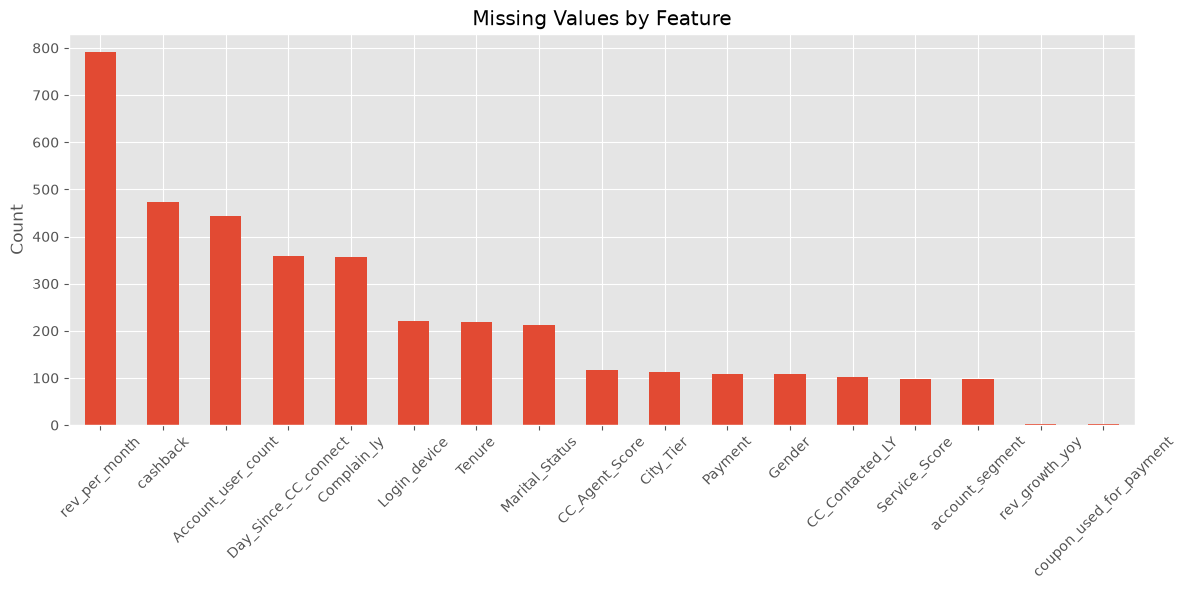

In [8]:
plt.figure(figsize=(12,6))

missing.plot(kind="bar")

plt.title("Missing Values by Feature")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/figures/missing_values.png")

plt.show()

## Target Variable Distribution

Understanding whether complaint classes are balanced or imbalanced.

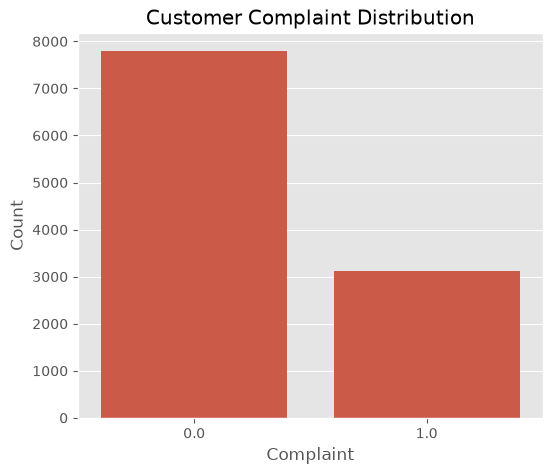

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Complain_ly",
    data=df
)

plt.title("Customer Complaint Distribution")

plt.xlabel("Complaint")

plt.ylabel("Count")

plt.savefig("../reports/figures/complaint_distribution.png")

plt.show()

In [10]:
df["Complain_ly"].value_counts(normalize=True) * 100

Complain_ly
0.0    71.466569
1.0    28.533431
Name: proportion, dtype: float64

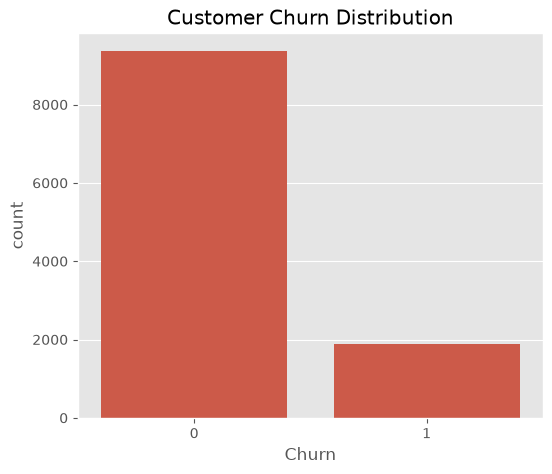

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")

plt.savefig("../reports/figures/churn_distribution.png")

plt.show()

## Distribution of Numerical Features

In [13]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

numeric_cols

Index(['AccountID', 'Churn', 'Tenure', 'City_Tier', 'CC_Contacted_LY',
       'Service_Score', 'Account_user_count', 'CC_Agent_Score',
       'rev_per_month', 'Complain_ly', 'rev_growth_yoy',
       'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback'],
      dtype='str')

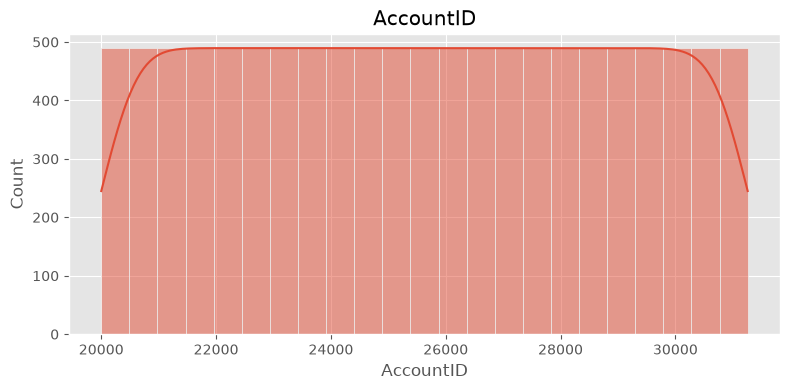

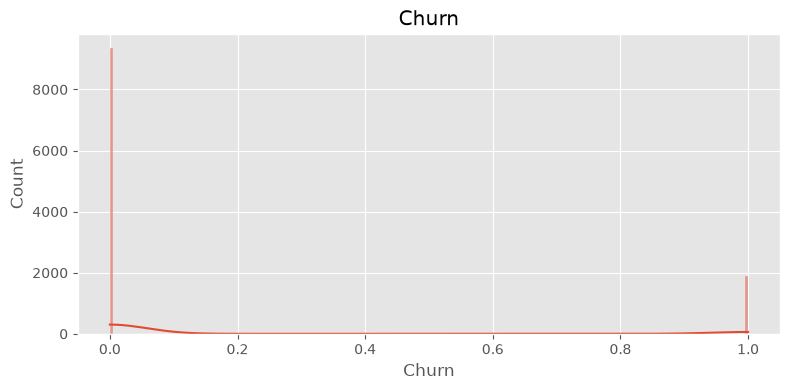

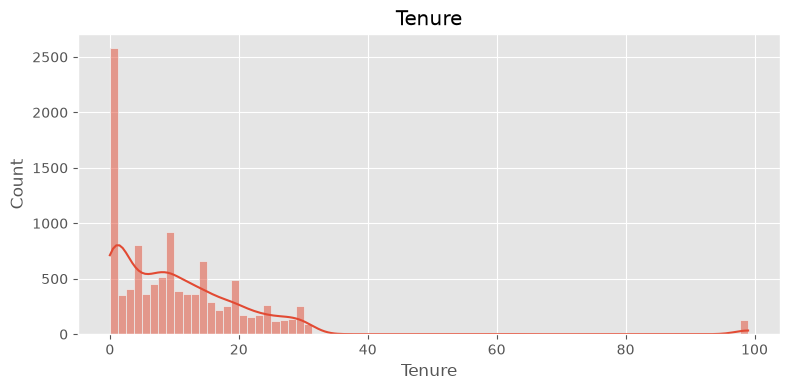

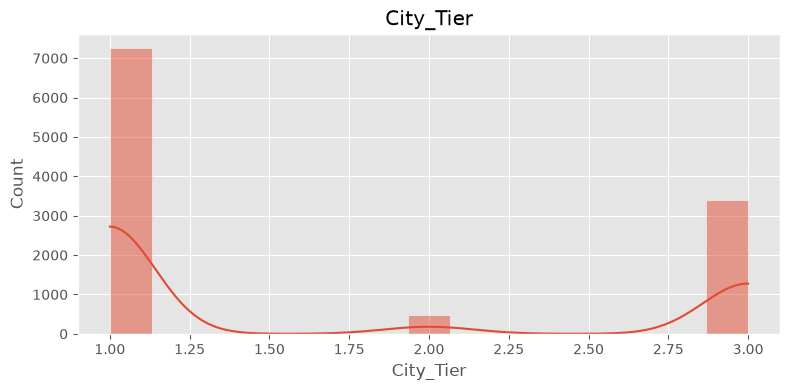

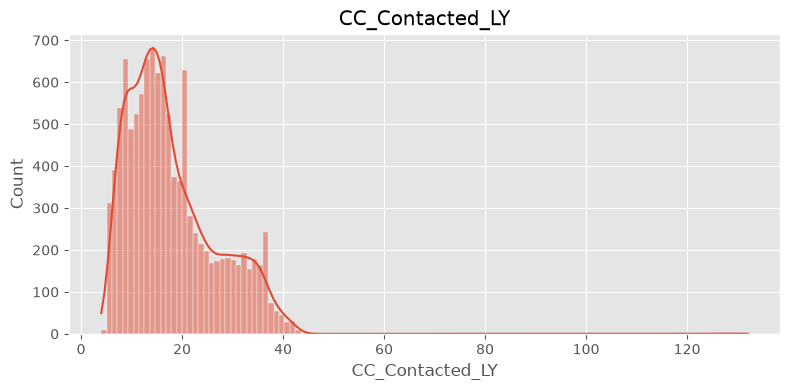

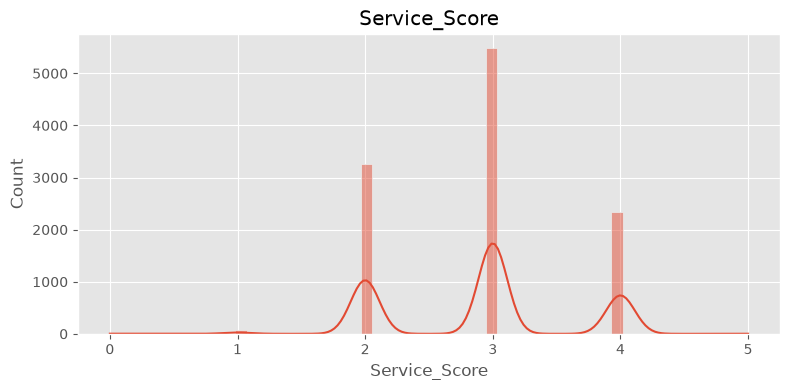

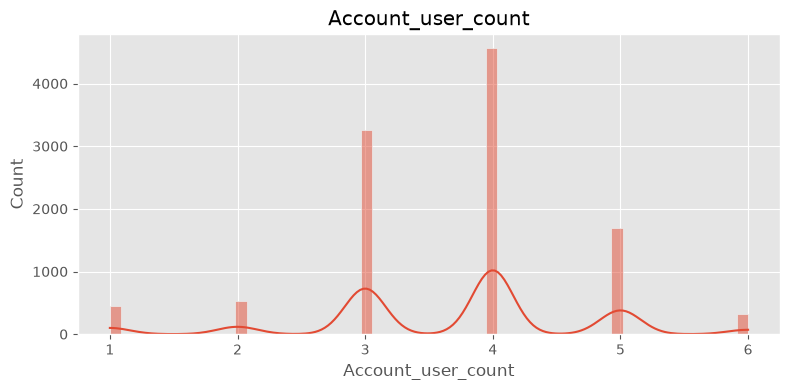

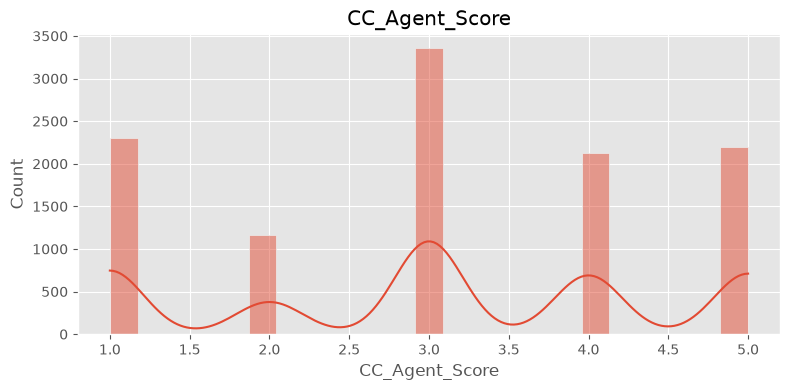

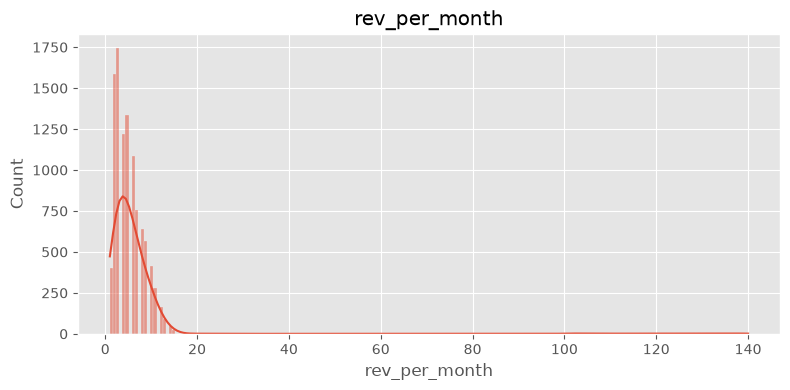

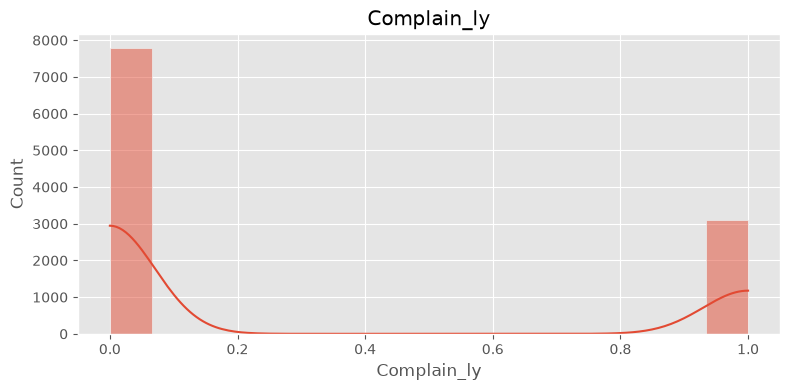

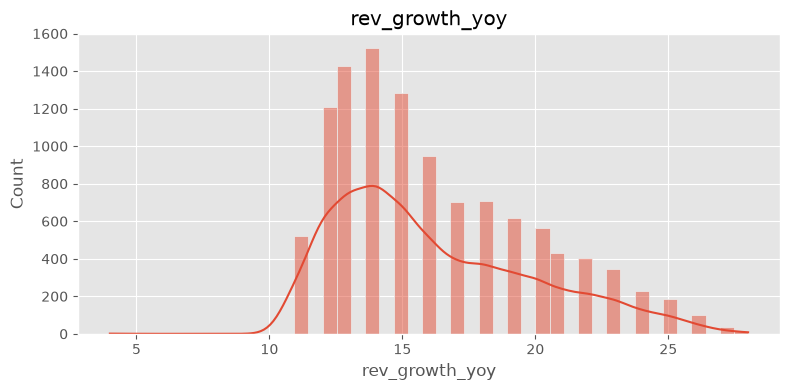

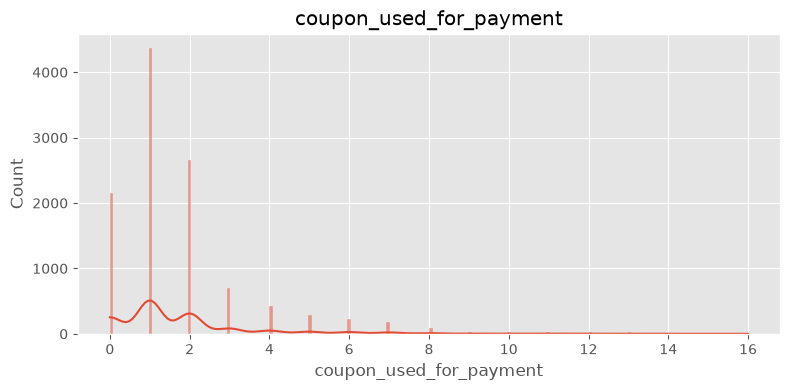

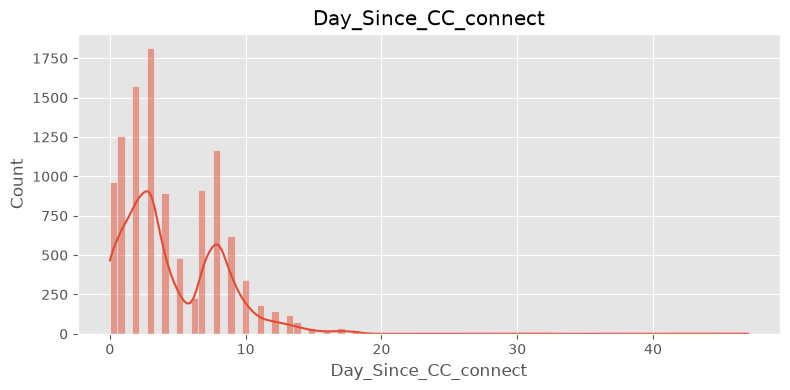

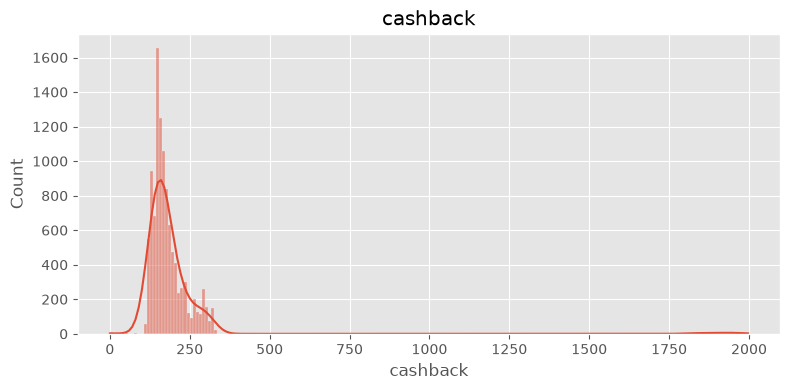

In [14]:
for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.tight_layout()

    plt.savefig(f"../reports/figures/{col}_hist.png")

    plt.show()

In [15]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

C:\Users\amish\AppData\Local\Temp\ipykernel_5032\2424776929.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


Index(['Payment', 'Gender', 'account_segment', 'Marital_Status',
       'Login_device'],
      dtype='str')

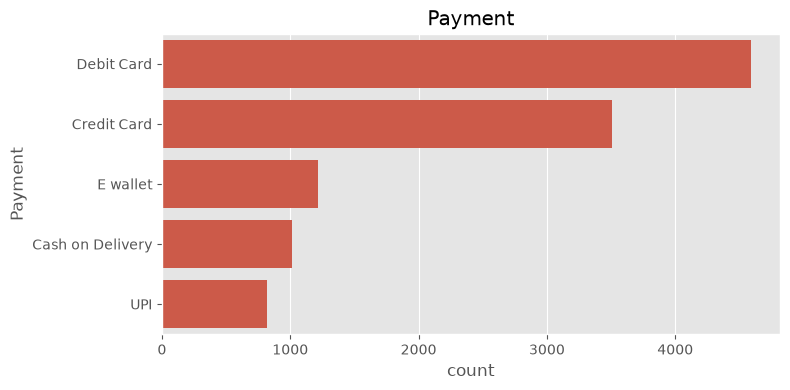

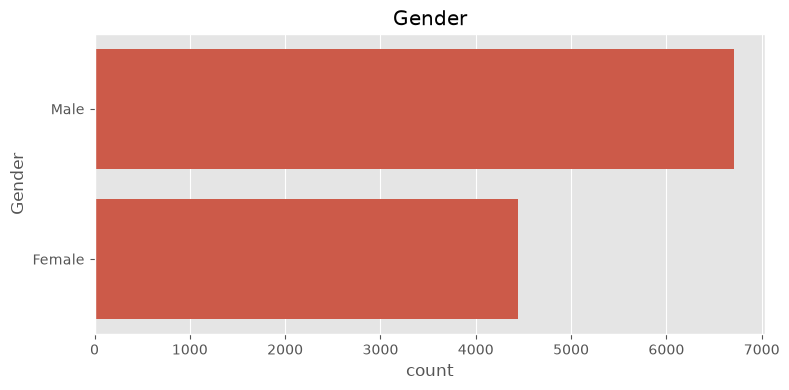

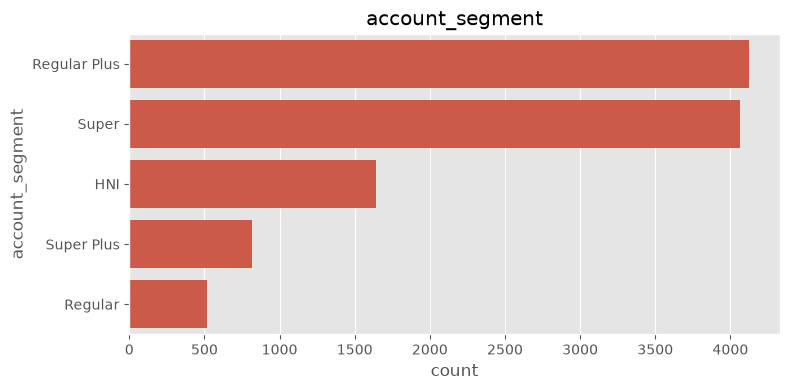

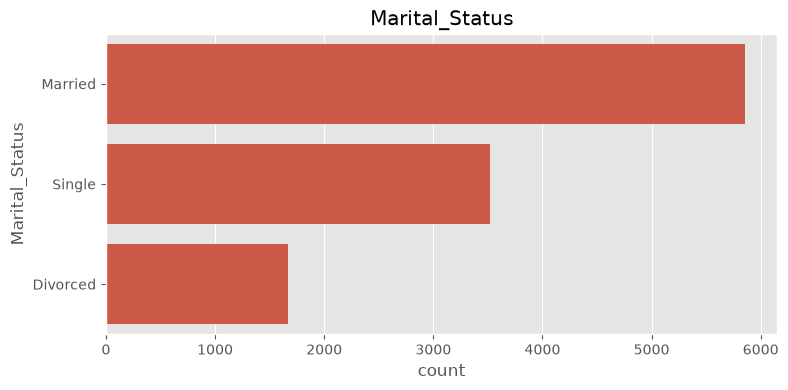

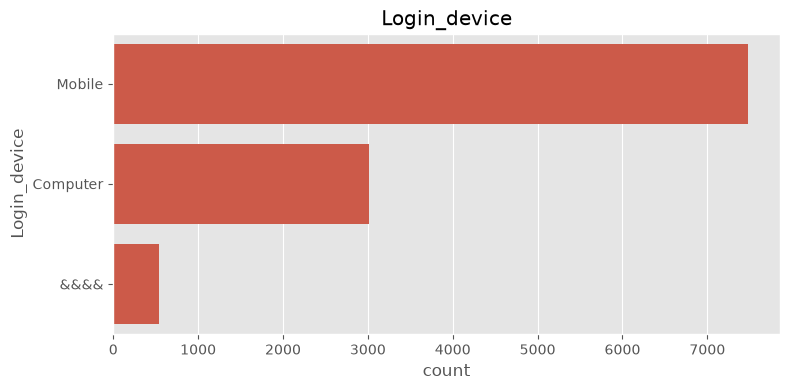

In [16]:
for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index
    )

    plt.title(col)

    plt.tight_layout()

    plt.savefig(f"../reports/figures/{col}_count.png")

    plt.show()

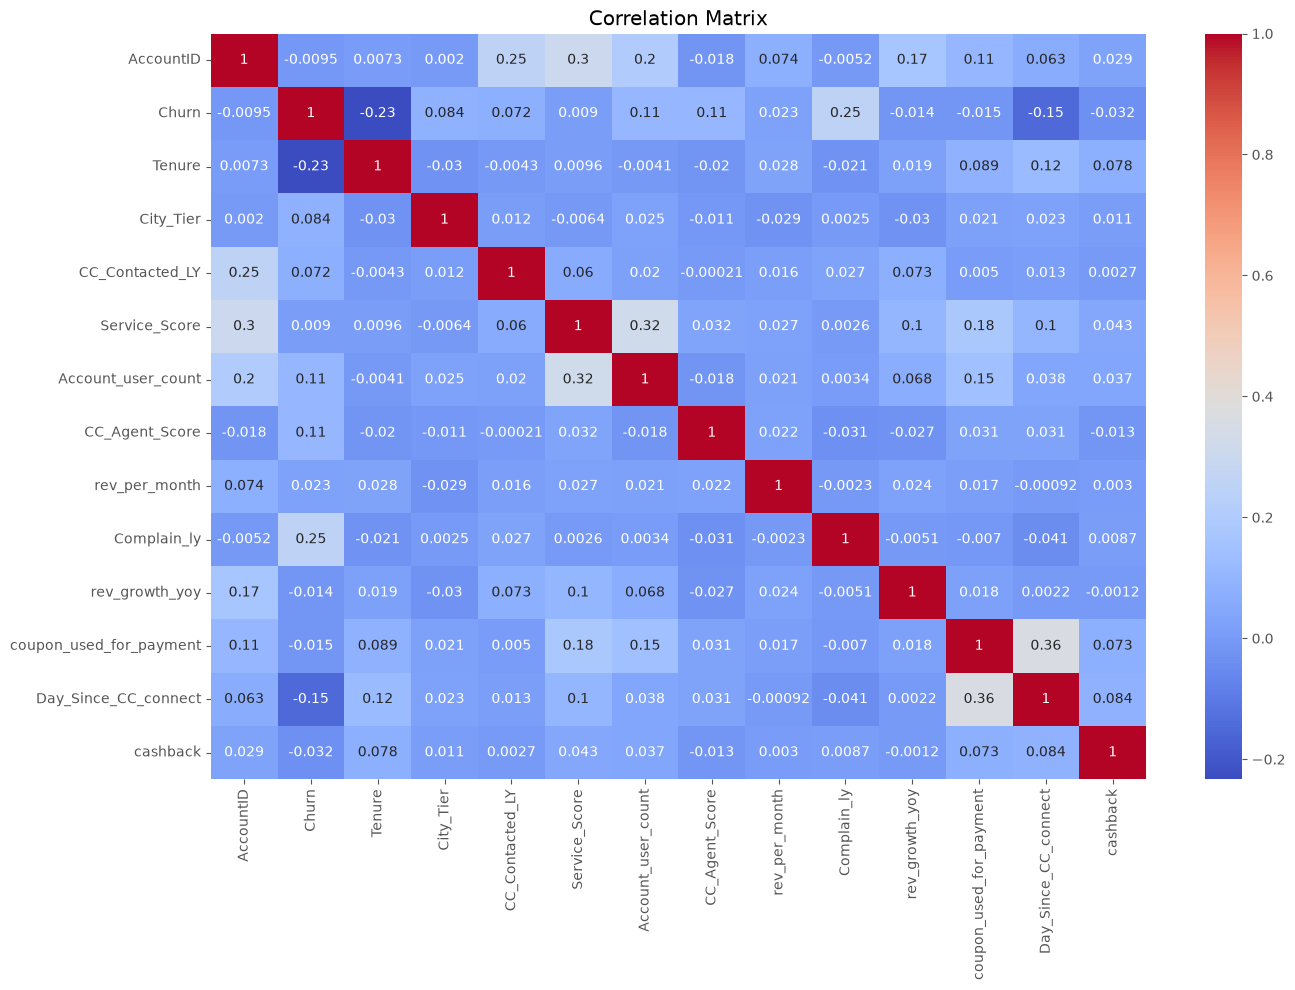

In [17]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig("../reports/figures/correlation_heatmap.png")

plt.show()

In [18]:
complaint_rate = df["Complain_ly"].value_counts(normalize=True) * 100

print(f"No Complaint: {complaint_rate[0]:.2f}%")
print(f"Complaint: {complaint_rate[1]:.2f}%")

No Complaint: 71.47%
Complaint: 28.53%


# Key Business Insights

### Complaint Behaviour

- Complaint rate is approximately 28.53%.

- Customers with lower service scores appear more likely to complain.

- Higher customer care interactions are associated with complaints.

### Revenue

- Revenue distribution is heavily right-skewed.

### Customer Segments

- Regular Plus customers form the largest customer segment.

### Churn

- Customers who complain exhibit a higher churn tendency.

## Complaint vs Service Score

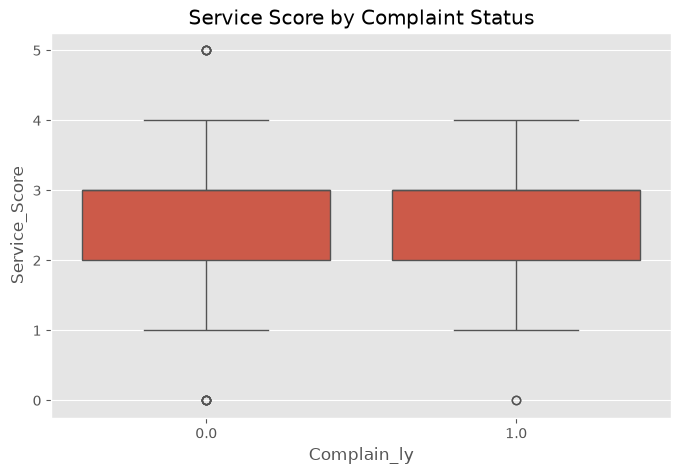

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Complain_ly",
    y="Service_Score",
    data=df
)

plt.title("Service Score by Complaint Status")

plt.savefig("../reports/figures/service_score_vs_complaint.png")

plt.show()

## Customer Care Contacts vs Complaint

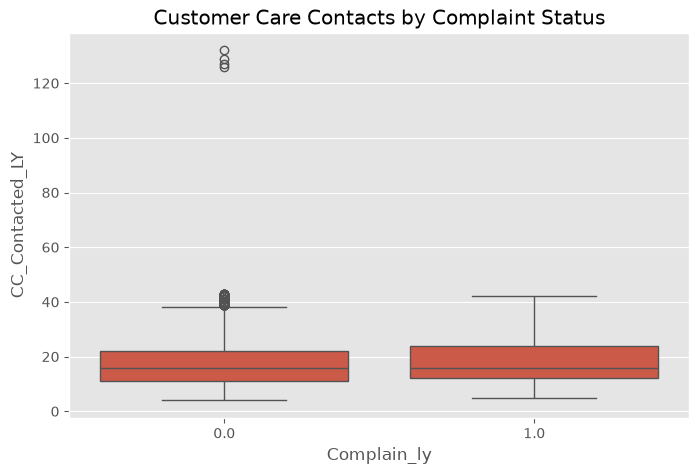

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Complain_ly",
    y="CC_Contacted_LY",
    data=df
)

plt.title("Customer Care Contacts by Complaint Status")

plt.savefig("../reports/figures/cc_contact_vs_complaint.png")

plt.show()

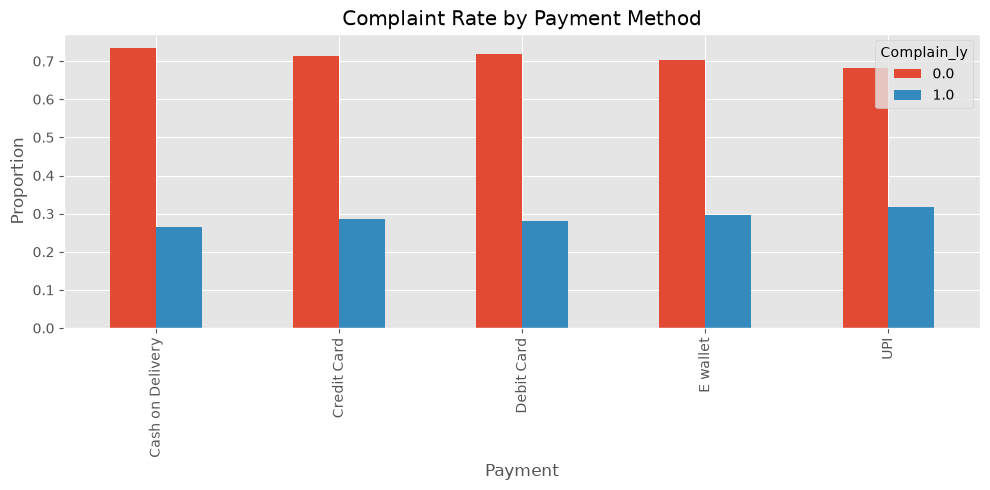

In [21]:
complaint_payment = pd.crosstab(
    df["Payment"],
    df["Complain_ly"],
    normalize="index"
)

complaint_payment.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Complaint Rate by Payment Method")

plt.ylabel("Proportion")

plt.tight_layout()

plt.savefig("../reports/figures/payment_vs_complaint.png")

plt.show()

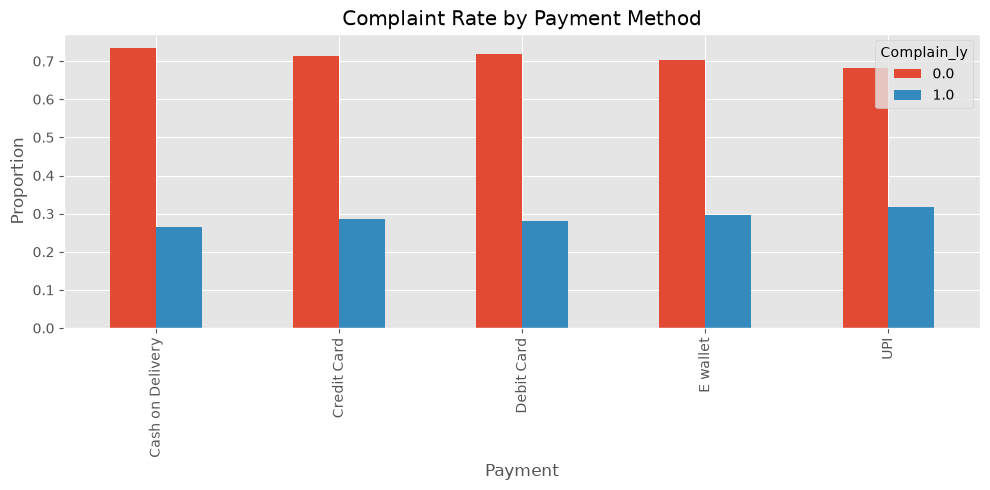

In [22]:
complaint_payment = pd.crosstab(
    df["Payment"],
    df["Complain_ly"],
    normalize="index"
)

complaint_payment.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Complaint Rate by Payment Method")

plt.ylabel("Proportion")

plt.tight_layout()

plt.savefig("../reports/figures/payment_vs_complaint.png")

plt.show()

# Conclusion

## Summary

This exploratory analysis identified several factors associated with customer complaints.

### Key Findings

- Approximately **28.53%** of customers raised a complaint.
- Complaint behaviour is associated with lower service scores.
- Customers with more customer-care interactions tend to complain more frequently.
- Revenue is heavily right-skewed, indicating a small number of high-value customers.
- Regular Plus is the largest customer segment.
- The dataset contains moderate class imbalance that should be considered during model training.

### Next Steps

- Handle missing values.
- Encode categorical variables.
- Scale numerical features where appropriate.
- Train and compare multiple classification models.
- Select the best-performing model for deployment.